In [37]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
base_path = Path(".") # change to path folder with data


# Wczytanie i przygotowanie danych


In [39]:
data_path= '/content/drive/MyDrive/ML-wakacyjne-wyzwanie-2026/titanic.csv'
titanic_df = pd.read_csv(data_path, index_col='PassengerId')

Na początek sprawdzimy jakie cechy posiada nasz zestaw danych i jakiego są one typu.


In [40]:

titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


Nie wszystkie kolumny mają odpowiedni typ danych. "Sex" oraz "Embarked" powinny być przekonwertowane na cechy kategorialne porządkowe.


In [41]:
titanic_df['Sex']=titanic_df['Sex'].astype('category')
titanic_df['Embarked']=titanic_df['Embarked'].astype('category')


Wśród cech znajdują się też te, które nie mają wpływu na analizę. Kolumny "Name", czy "Ticket" to dla algorytmów ciągi "losowych" znaków. Należy więc te atrybuty usunąć.

In [42]:
titanic_df.drop(columns=["Name","Ticket"])

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,NaN,S
2,1,1,female,38.0,1,0,71.2833,C85,C
3,1,3,female,26.0,0,0,7.9250,NaN,S
4,1,1,female,35.0,1,0,53.1000,C123,S
5,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,NaN,S
888,1,1,female,19.0,0,0,30.0000,B42,S
889,0,3,female,NaN,1,2,23.4500,NaN,S


Po przekonwertowaniu możemy sprawdzić, w których kolumnach występują wartości brakujące i jaki procent danych stanowią.

In [43]:
#Funkcja z pliku EDA_sciaga.ipynb
def get_percentage_missing(df, axis):
  """
    Zwraca procent brakujących wartości (NaN) w wierszach lub kolumnach DataFrame.

    df : pandas.DataFrame
        Tabela danych, dla której liczone są braki.

    axis : int
        Oś, względem której obliczane są braki:
        - 0 : procent braków w każdej kolumnie
        - 1 : procent braków w każdym wierszu
  """
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

missing_cols_mi = get_percentage_missing(titanic_df, axis=0)
missing_cols_mi


,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Największy odsetek danych brakujących znajduje się w kolumnie "Cabin". Pozostałe kolumny to "Age", "Fare", a także "Embarked".

Pod kątem dalszej analizy wpływu cech na fakt przeżycia pasażera numer kabiny (kolumna Cabin) nie ma znaczącego wpływu na badane zależności. Bez dokładniejszej wiedzy o statku numer kajuty zostanie tylko nieznaczącą cyfrą.

Z kolei wiek, port, z którego pasażer wypływał oraz cena biletu mogły mieć większy wpływ na losy pasażerów.

Aby oczyścić dane musimy pozbyć się wartości brakujących.


In [44]:
#Funkcja z pliku EDA_sciaga.ipynb
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)
age=get_column_distribution(titanic_df,"Age")
missing= titanic_df.Age.isna()
titanic_df.loc[missing, 'Age'] = np.random.choice(age.index, size=missing.sum(), p=age.values)
price=get_column_distribution(titanic_df,"Fare")
missing1= titanic_df.Fare.isna()
titanic_df.loc[missing1, 'Fare'] = np.random.choice(price.index, size=missing1.sum(), p=price.values)
titanic_df['Cabin']=titanic_df['Cabin'].fillna("Unknown")
mode1=titanic_df['Embarked'].mode()[0]
titanic_df['Embarked']=titanic_df['Embarked'].fillna(mode1)

titanic_df.isna().sum()


,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


Musimy teraz utworzyć nowe kolmny. Jedną z nim będzie kraj, z którego odpływała dana jednostka. Natomiast drugą będzie określenie kategorii wiekowej pasażera (tj. czy był dzieckiem, dorosłym albo seniorem).

In [59]:
countries={"C":"France",
       "Q":"Irland",
       "S":"England"}
titanic_df["Country"]=titanic_df['Embarked'].map(countries)

def agegroup(age):
  if age<18:
    return "Child"
  elif age>60:
    return "Senior"
  else:
    return "Adult"

titanic_df["Age_group"]=titanic_df["Age"].apply(agegroup)

Nasze dane prezentują się teraz w następujący sposób.

In [60]:
titanic_df.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Country,Age_group
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,England,Adult
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,France,Adult
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,England,Adult
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,England,Adult
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,England,Adult


# Wizualizacja

Dla lepszego zrozumienia danych zwizualizujemy je aby sprawdzić jak m.in.prezentują się rozkłady poszczególnych cech, czy mają wartości odstające, wyraźne zależności między sobą itd.

## Analiza poszczgólnych cech




**1.   Czy pasażer przeżył**

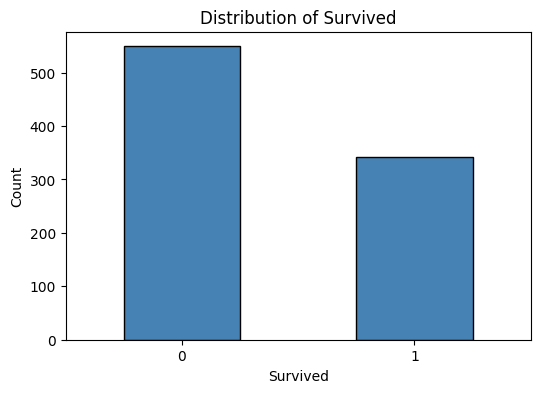

In [47]:
#Funkcja z pliku EDA_sciaga.ipynb
def plot_categorical_column(df, column_name):
    """
    Plots a bar chart for the specified categorical column.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """

    # count occurrences of each category
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

plot_categorical_column(titanic_df,"Survived")

Rozkład prezentuje, znaczącą przewagę pasażerów, których nie udało się uratować.

**2. Klasa podróży**

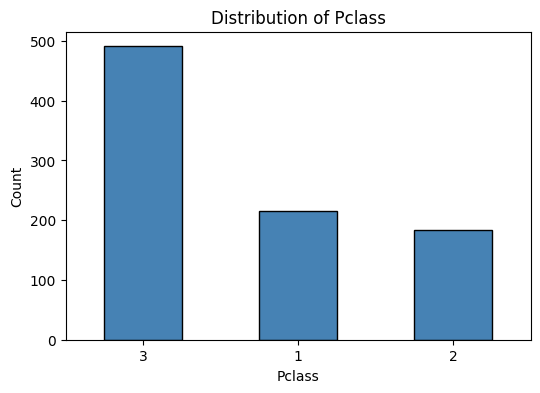

In [48]:
plot_categorical_column(titanic_df,"Pclass")

Na statku występowała wyraźna dysproporcja między klasami. Zdecydowana większość pasażerów należała do najuboższej z nich.

3. **Płeć**

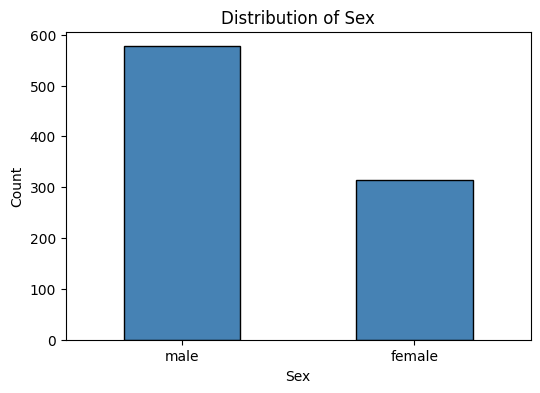

In [49]:
plot_categorical_column(titanic_df,"Sex")

Z danych możemy wysnioskować, iż na pokładzie Tytanica było dwukrotnie więcej mężczyzn niż kobiet.

**4. Wiek i grupy wiekowe**

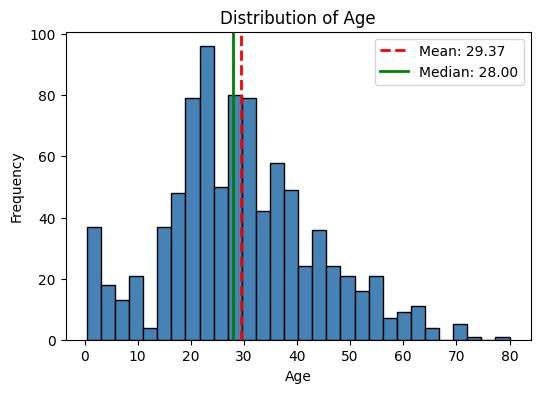

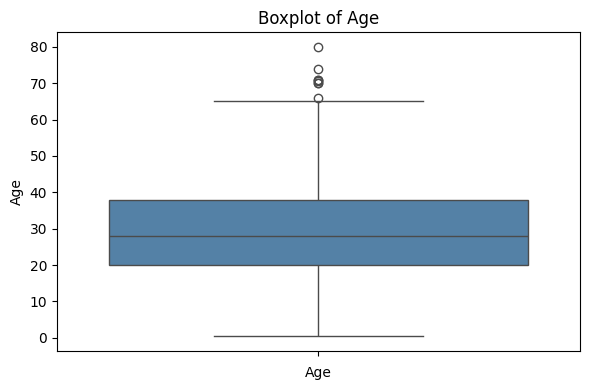

In [61]:
#poprawiona o wykres pudełkowy funkcja z pliku EDA_sciaga.ipynb
def plot_numeric_histogram(df, column_name):
    """
    Plots a histogram for the specified column in the DataFrame,
    and adds vertical lines for the mean and median. Also plots a boxplot with outliners.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot.
    Returns:
        None. Displays the histogram.
    """

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()


    plt.figure(figsize=(6, 4))
    sns.boxplot(data,color='steelblue')
    plt.title(f"Boxplot of {column_name}")
    plt.xlabel(column_name)
    plt.tight_layout()
    plt.show()

plot_numeric_histogram(titanic_df,"Age")

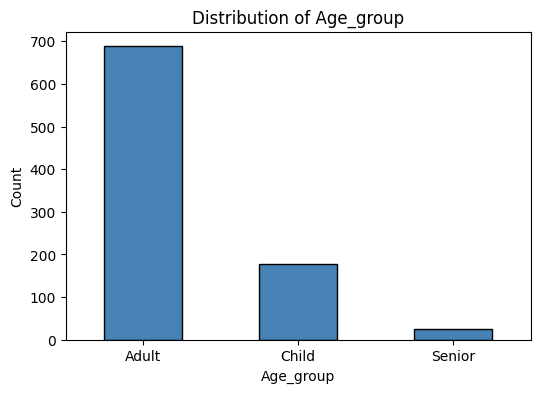

In [51]:
plot_categorical_column(titanic_df,"Age_group")

Z rysunków wynika, że dominującą grupą wiekową byli dorośli. Było ich znacząco więcej niż dzieci i osób starszych łącznie. Można też zauważyć, że osoby powyżej 70 roku życia stanowiły bardzo nieliczną grupę, którą możemy uznać za wartości odstające. Ponadto, wiek pasażerów układa się w rozkład z lekką tendencją do prawostronnej skośności.  

**5. Liczba rodzeństwa, rodziców, małżonków i dzieci na pokładzie**

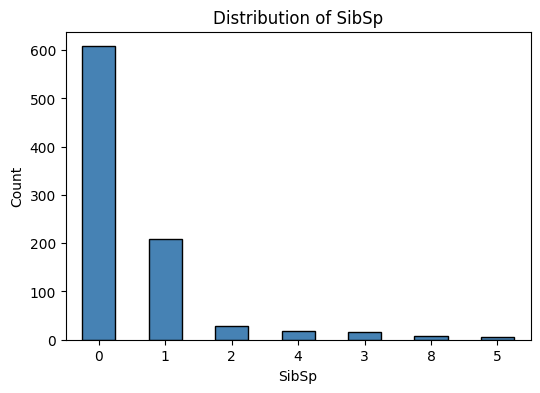

In [52]:
plot_categorical_column(titanic_df,"SibSp")

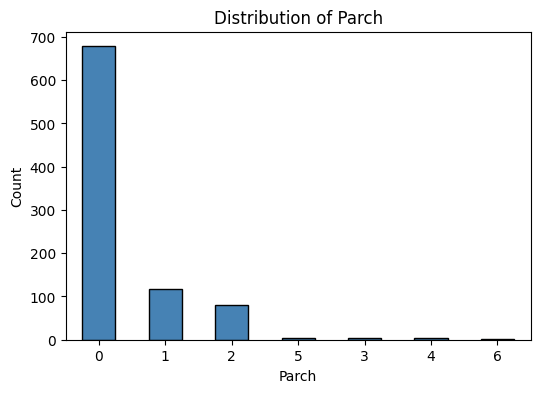

In [53]:
plot_categorical_column(titanic_df,"Parch")

Z powyższych wykresów wynika, iż najwięcej podróżnych wypłynęło na rejs samodzielnie. Co więcej z pierwszego z nich wynika, iż popularną opcją była również podróż z żoną/małżonkiem lub jednym z rodzeństwa. Rysunki przedstawiają również nietypowe wartości, jakimi były podróże z dużą rodziną. Niespotykane było zarówno bycie na statku z więcej niż 3 rodzeństwa, jak i posiadanie więcej niż 3 dzieci.

**6. Cena biletu**

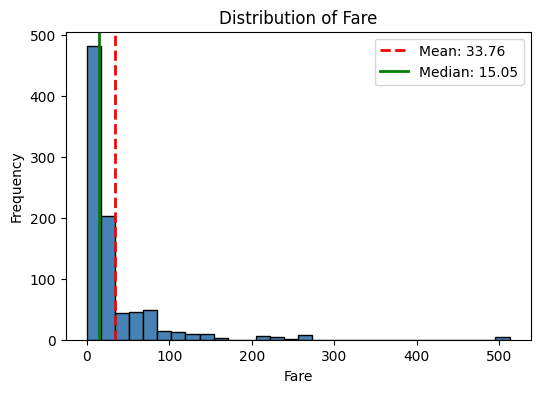

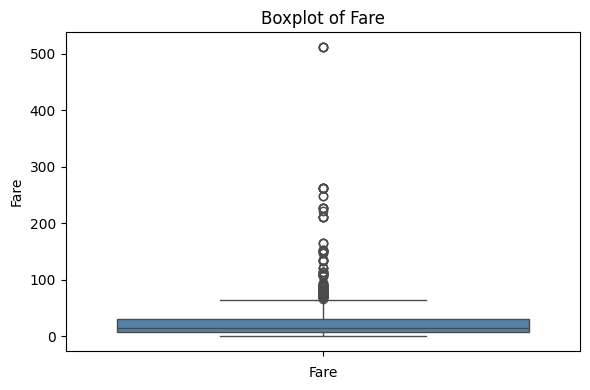

In [54]:
plot_numeric_histogram(titanic_df,"Fare")

Patrząc na fakt, iż najliczniejszą klasą była ta najuboższa, nie jest dziwne, że najwięcej zostało sprzedanych najtańszych biletów. Rozkład tych cen jest wyraźnie prawo skośny. Ponadto najdroższe bilety to wartości odstające, które na tle tańszych opcji były mniej wybieralne.

**7. Numer kabiny**

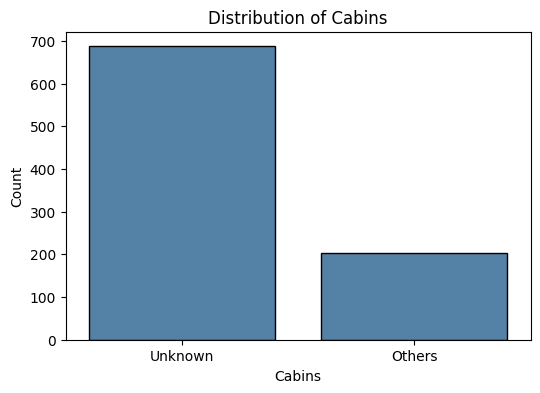

In [55]:
unknown= (titanic_df['Cabin']=="Unknown").sum()
known=len(titanic_df)-unknown
names= ["Unknown", "Others"]
values = [unknown,known]
plt.figure(figsize=(6, 4))
sns.barplot(x=names,y=values,color="steelblue",edgecolor="black")
plt.title("Distribution of Cabins")
plt.xlabel("Cabins")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Znacząca większość numerów kabin pozostała nieznana. Może to być połączone z cenami biletów i ilością pasażerów z najuboższej klasie.

**8. Port i kraj, w którym pasażer wsiadł**

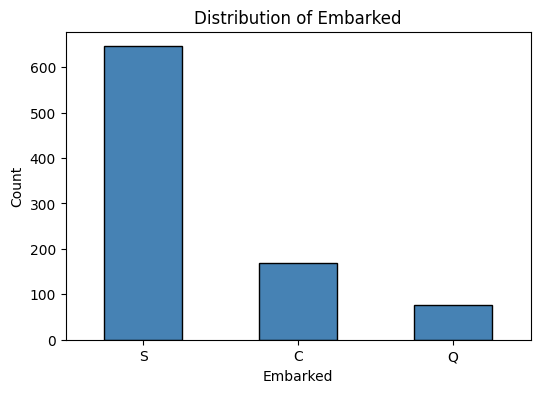

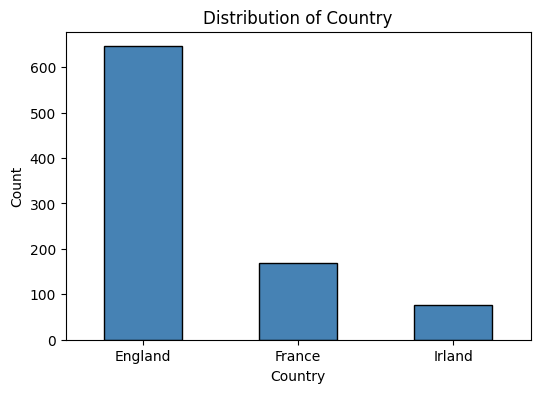

In [56]:
plot_categorical_column(titanic_df,"Embarked")
plot_categorical_column(titanic_df,"Country")

Wykresy przedstawiają te same rozkłady, aczkolwiek bez znajomości danych, drugi wykres jest zrozumiały dla czytelnika. Najwięcej osób wypływało z Anglii. Pasażerowie zaczynający podróż z Francji lub Irlandi stanowili około 25% wszytskich płynących na statku.


# Zakodowanie cech kategorialnych


Po utworzeniu i wizualizacji
wszystkich cech widać, że wśród nich są zmienne kategorialne porządkowe. Aby algorytmy były w stanie poprawnie działać musimy zakodować je do posatci liczbowej. Płeć, port oraz kraj nie mają z góry narzuconej hierarchi dlatego do ich kodowania użyjemy one-hot encoding. Natomiast dla kategorii wiekowej pasażerów moim zdaniem jesteśmy w stanie określić ich uporządkowanie, gdyż najprędzej ratowano dzieci, później dorosłych a na końcu starców. Stąd też dla tej kolumny użyjemy ordinal encoding.

In [63]:
one_hot_encoded_countries = pd.get_dummies(data=titanic_df, columns=['Sex', 'Embarked','Country'], dtype=np.int32)
age={"Child":1,
      "Adult":2,
      "Senior":3}
titanic_df['Age_group']=titanic_df['Age_group'].map(age)


Po dokonanym przekodowaniu nasze dane są gotowe do analizy.

## Szukanie podstawowych zależności między atrybutami


Do znalezenia współzależności wśród badanych cech wykorzytsamy macierz korelacji oraz wykres mapy cieplnej.

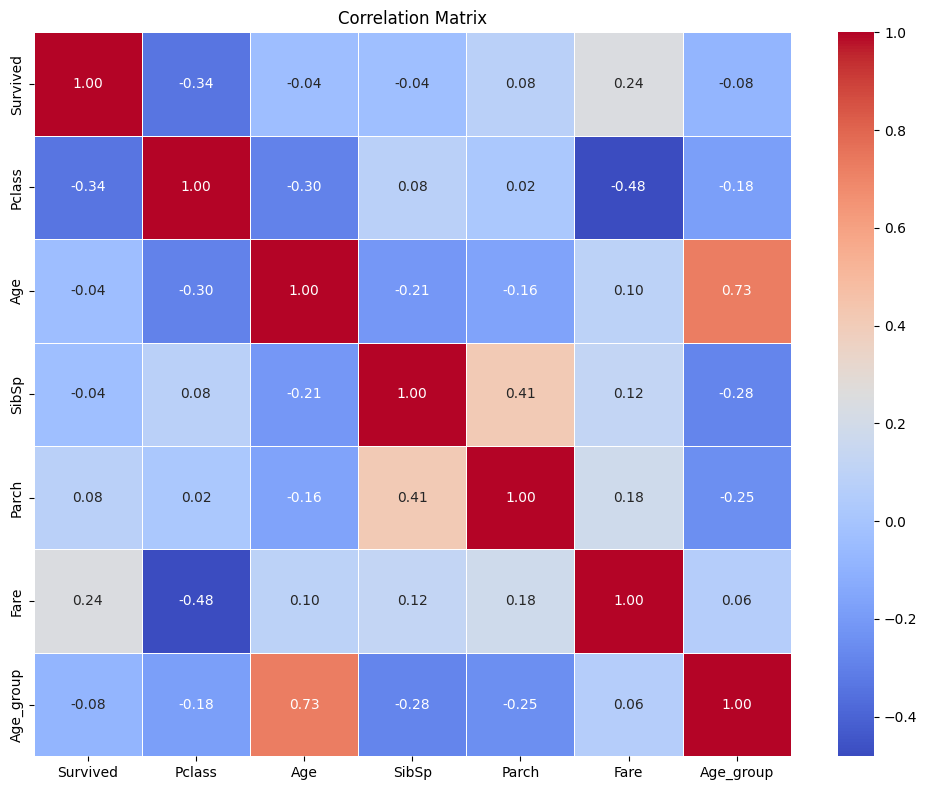

In [64]:
#Funkcja z pliku EDA_sciaga.ipynb
def plot_correlation_matrix(df):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(titanic_df)

Największa zależność występuje między wiekiem, a grupą wiekową, co nie jest niczym zaskakującym. Podobnie w przypadku ilości rodzeństwa lub partnera, a rodziców i dzieci. Niespotykana jest jednak ujemna korelacja między klasą a ceną biletu. Moim zdaniem na tym etapie nie warto wizualizować cechy parami.